# Data Mining_2_Module_2
## Advanced Machine Learning, Classification and Explainability

It starts directly from the **outlier-cleaned output of Module 1** and executes:

1. common preprocessing for the three-class `sii` classification task;
2. Logistic Regression;
3. four SVM kernels;
4. scikit-learn MLP;
5. a cost-sensitive PyTorch deep neural network and the additional NN checks used in the project;
6. Random Forest and Extra Trees;
7. XGBoost;
8. a unified classification comparison;
9. SHAP global/local explainability;
10. LORE local rules and counterfactuals, when the project-local LORE dependency is available;
11. saving of model artefacts, metrics.

## 0. Dependencies and project paths

Required Python packages:

```bash
pip install numpy pandas matplotlib scikit-learn scipy joblib xgboost lightgbm torch imbalanced-learn shap
```

In [ ]:
pip install numpy pandas matplotlib scikit-learn scipy joblib xgboost lightgbm torch imbalanced-learn shap

In [1]:
from pathlib import Path
from collections import Counter
import importlib
import json
import time
import warnings
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

RANDOM_STATE = 42
TEST_SIZE = 0.30

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

PROJECT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2"),
    Path("/Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2"),
    Path("/Users/sarabiiavasco/Codice/DATA MINING/progetto dm2"),
]

def looks_like_project_dir(path):
    return (
        path.exists()
        and (
            (path / "data").exists()
            or (path / "artifacts").exists()
        )
    )

PROJECT_DIR = next(
    (p for p in PROJECT_CANDIDATES if looks_like_project_dir(p)),
    None,
)

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Project directory not found. Update PROJECT_CANDIDATES."
    )

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "module2"
CLASSIFICATION_DIR = ARTIFACT_DIR / "classification"
XAI_DIR = ARTIFACT_DIR / "xai"

for directory in [
    PROCESSED_DIR,
    ARTIFACT_DIR,
    CLASSIFICATION_DIR,
    XAI_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Module 2 artifacts:", ARTIFACT_DIR)

Project directory: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2
Module 2 artifacts: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module2


# Advanced Classification

## 1. Load the Module 1 output

The only preferred input for the final Module 2 classification is:

`data/processed/06_module1_after_outlier_removal.csv`

In [2]:
MODULE1_CANDIDATES = [
    PROCESSED_DIR / "06_module1_after_outlier_removal.csv",
    PROJECT_DIR / "06_module1_after_outlier_removal.csv",
]

# Historical fallback, accepted only with an explicit warning.
MODULE1_CANDIDATES += list(PROJECT_DIR.rglob("dataset_finale_da_usare_per_tutto.csv"))

MODULE1_DATASET_PATH = next(
    (p for p in MODULE1_CANDIDATES if p.exists()),
    None,
)

if MODULE1_DATASET_PATH is None:
    raise FileNotFoundError(
        "Module 1 output not found. Run DM2_Module1_FULL_PIPELINE.ipynb first."
    )

df_module2 = pd.read_csv(MODULE1_DATASET_PATH)

print("Loaded:", MODULE1_DATASET_PATH)
print("Shape:", df_module2.shape)

if MODULE1_DATASET_PATH.name != "06_module1_after_outlier_removal.csv":
    warnings.warn(
        "A historical fallback dataset was loaded. For the final repository, "
        "Module 2 should use 06_module1_after_outlier_removal.csv produced by Module 1."
    )

if df_module2.shape != (8253, 30):
    warnings.warn(
        "The loaded dataset does not match the final report checkpoint (8253, 30). "
        "Current results may differ from the report."
    )

display(df_module2.head())

Loaded: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/data/processed/06_module1_after_outlier_removal.csv
Shape: (8286, 30)


/var/folders/b4/hvnr8by950nd8ffj3bwdqh3w0000gn/T/ipykernel_32456/1177167280.py:31: UserWarning: The loaded dataset does not match the final report checkpoint (8253, 30). Current results may differ from the report.
  warnings.warn(


,sii,PCIAT-PCIAT_Total,Physical-BMI_recalc,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Max_Stage,FGC-FGC_CU,FGC-FGC_GSND,FGC-FGC_GSD,FGC-FGC_PU,FGC-FGC_TL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_ECW,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,SDS-SDS_Total_Raw,PreInt_EduHx-computerinternet_hoursday,PAQ_Total,Fitness_Endurance-Time_Total_Sec,FGC-FGC_SR_Mean,FGC-FGC_SR_Asymmetry
0,2.0,55.0,16.860704,5.0,0.0,51.0,46.0,50.75,26.0,68.0,87.0,114.0,5.0,0.0,20.00,20.75,0.0,6.0,2.0,2.66855,8.25598,9.21377,1.0,24.434900,42.0,3.0,3.0,448.0,6.5,1.0
1,0.0,0.0,14.035590,9.0,0.0,61.0,48.0,46.00,22.0,75.0,70.0,122.0,5.0,3.0,16.75,19.75,5.0,3.0,2.0,2.57949,6.01993,3.97085,1.0,21.035200,46.0,0.0,2.0,448.0,11.0,0.0
2,0.0,28.0,16.626674,10.0,1.0,71.0,56.5,75.50,26.0,65.0,94.0,117.0,5.0,20.0,10.25,14.75,7.0,5.0,3.0,3.92272,15.92800,16.17460,2.0,28.863158,38.0,2.0,2.0,453.0,10.0,0.0
3,1.0,44.0,18.269930,9.0,0.0,71.0,56.0,81.50,26.0,60.0,97.0,117.0,6.0,18.0,20.00,21.00,5.0,7.0,3.0,3.84191,15.59250,18.82430,2.0,30.404100,31.0,0.0,2.0,577.0,7.0,0.0
4,0.0,NaN,17.894545,18.0,1.0,65.0,55.0,77.00,26.0,68.0,81.0,114.0,5.0,9.0,20.00,21.25,3.0,10.0,3.0,3.92272,15.92800,16.17460,2.0,28.855800,41.0,1.0,1.0,448.0,9.0,0.0


## 2. Three-class target and shared preprocessing

The original `sii` classes are:

- 0 = None
- 1 = Mild
- 2 = Moderate
- 3 = Severe

The final classification merges classes **2 and 3** into `Moderate+Severe` because the Severe class is too small to be learned reliably on its own.

`PCIAT-PCIAT_Total` is removed from predictors because it is the source score from which `sii` is derived.

The split and scaler are created **once** here and reused by every classifier and by XAI.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

CLASS_LABELS = {
    0: "None",
    1: "Mild",
    2: "Moderate+Severe",
}

df_class = df_module2.copy(deep=True)
df_class["sii_3class"] = df_class["sii"].replace({3: 2}).astype(int)

X_class = (
    df_class
    .drop(columns=["sii", "sii_3class", "PCIAT-PCIAT_Total"], errors="ignore")
    .copy()
)
y_class = df_class["sii_3class"].copy()

X_class = pd.get_dummies(
    X_class,
    drop_first=True,
    dtype=int,
)

feature_names = X_class.columns.tolist()

all_idx = np.arange(len(df_class))

train_idx, test_idx = train_test_split(
    all_idx,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_class,
)

X_train_raw = X_class.iloc[train_idx].copy()
X_test_raw = X_class.iloc[test_idx].copy()
y_train = y_class.iloc[train_idx].copy()
y_test = y_class.iloc[test_idx].copy()

classification_scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    classification_scaler.fit_transform(X_train_raw),
    columns=feature_names,
    index=X_train_raw.index,
)

X_test_scaled = pd.DataFrame(
    classification_scaler.transform(X_test_raw),
    columns=feature_names,
    index=X_test_raw.index,
)

print("Full three-class distribution:")
display(
    y_class.value_counts().sort_index().rename("count").to_frame()
)

print("Training set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)
print("Training distribution:")
display(y_train.value_counts().sort_index().rename("count").to_frame())
print("Test distribution:")
display(y_test.value_counts().sort_index().rename("count").to_frame())

if len(df_class) == 8253:
    expected_train = {0: 3975, 1: 1092, 2: 710}
    expected_test = {0: 1703, 1: 468, 2: 305}
    if y_train.value_counts().sort_index().to_dict() != expected_train:
        warnings.warn("Training distribution differs from the report checkpoint.")
    if y_test.value_counts().sort_index().to_dict() != expected_test:
        warnings.warn("Test distribution differs from the report checkpoint.")

Full three-class distribution:


,count
sii_3class,
0,5705
1,1559
2,1022


Training set: (5800, 28)
Test set: (2486, 28)
Training distribution:


,count
sii_3class,
0,3993
1,1091
2,716


Test distribution:


,count
sii_3class,
0,1712
1,468
2,306


In [4]:
CLASSIFICATION_PREPROCESSING_PATH = CLASSIFICATION_DIR / "classification_preprocessing.joblib"

joblib.dump(
    {
        "feature_names": feature_names,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "scaler": classification_scaler,
        "class_labels": CLASS_LABELS,
    },
    CLASSIFICATION_PREPROCESSING_PATH,
)

print("Saved:", CLASSIFICATION_PREPROCESSING_PATH)

Saved: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module2/classification/classification_preprocessing.joblib


## 3. Shared classification evaluation

Model selection is based primarily on **macro-F1** because the classes are strongly imbalanced.  
The held-out test set is never used during hyperparameter search.

In [5]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

classification_results = []
classification_models = {}
classification_best_params = {}

def classification_metrics_row(name, model, X_eval, y_eval):
    pred = model.predict(X_eval)
    prob = model.predict_proba(X_eval) if hasattr(model, "predict_proba") else None

    precision, recall, f1, support = precision_recall_fscore_support(
        y_eval,
        pred,
        labels=[0, 1, 2],
        zero_division=0,
    )

    row = {
        "model": name,
        "accuracy": accuracy_score(y_eval, pred),
        "macro_precision": float(np.mean(precision)),
        "macro_recall": float(np.mean(recall)),
        "macro_f1": f1_score(y_eval, pred, average="macro"),
    }

    for cls in [0, 1, 2]:
        row[f"class_{cls}_precision"] = precision[cls]
        row[f"class_{cls}_recall"] = recall[cls]
        row[f"class_{cls}_f1"] = f1[cls]
        row[f"class_{cls}_support"] = int(support[cls])

    if prob is not None:
        y_bin = label_binarize(y_eval, classes=[0, 1, 2])
        for cls in [0, 1, 2]:
            row[f"class_{cls}_auc"] = roc_auc_score(y_bin[:, cls], prob[:, cls])
            row[f"class_{cls}_ap"] = average_precision_score(y_bin[:, cls], prob[:, cls])

    classification_results.append(row)
    return row, pred, prob


def show_classification_result(name, model, X_eval=X_test_scaled, y_eval=y_test):
    row, pred, prob = classification_metrics_row(name, model, X_eval, y_eval)

    print(f"\n{name}")
    print("=" * len(name))
    print(
        classification_report(
            y_eval,
            pred,
            labels=[0, 1, 2],
            target_names=[CLASS_LABELS[i] for i in [0, 1, 2]],
            digits=4,
            zero_division=0,
        )
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_eval,
        pred,
        labels=[0, 1, 2],
        display_labels=[CLASS_LABELS[i] for i in [0, 1, 2]],
        ax=ax,
        colorbar=False,
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

    return row, pred, prob


def plot_multiclass_roc(name, y_true, probabilities):
    y_bin = label_binarize(y_true, classes=[0, 1, 2])

    fig, ax = plt.subplots(figsize=(7, 5))
    for cls in [0, 1, 2]:
        fpr, tpr, _ = roc_curve(y_bin[:, cls], probabilities[:, cls])
        auc_value = roc_auc_score(y_bin[:, cls], probabilities[:, cls])
        ax.plot(fpr, tpr, label=f"{CLASS_LABELS[cls]} (AUC={auc_value:.2f})")

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC — {name}")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_multiclass_pr(name, y_true, probabilities):
    y_bin = label_binarize(y_true, classes=[0, 1, 2])

    fig, ax = plt.subplots(figsize=(7, 5))
    for cls in [0, 1, 2]:
        precision, recall, _ = precision_recall_curve(
            y_bin[:, cls],
            probabilities[:, cls],
        )
        ap = average_precision_score(y_bin[:, cls], probabilities[:, cls])
        ax.plot(recall, precision, label=f"{CLASS_LABELS[cls]} (AP={ap:.2f})")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Precision–Recall — {name}")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4. Logistic Regression

The final search tests:

- `C ∈ {0.001, 0.01, 0.1, 1, 10, 100}`
- solvers `lbfgs`, `saga`
- `class_weight="balanced"`
- 5-fold CV.

We used macro-F1 as the common model-selection criterion.

Loaded cached Logistic Regression.
Best Logistic Regression params: 0.01 lbfgs

Logistic Regression
                 precision    recall  f1-score   support

           None     0.8015    0.6086    0.6919      1712
           Mild     0.2216    0.2415    0.2311       468
Moderate+Severe     0.2263    0.5000    0.3116       306

       accuracy                         0.5261      2486
      macro avg     0.4165    0.4500    0.4115      2486
   weighted avg     0.6216    0.5261    0.5583      2486



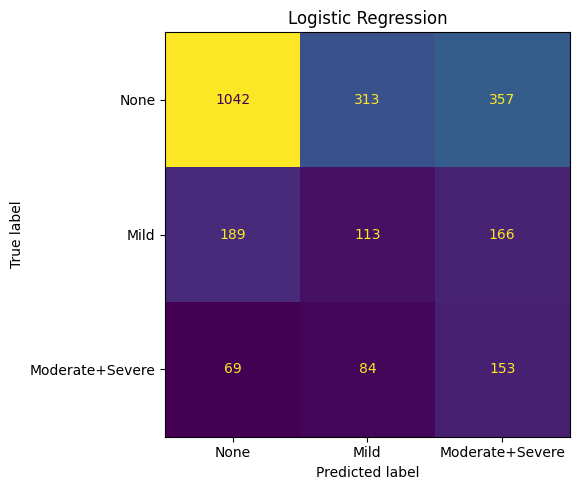

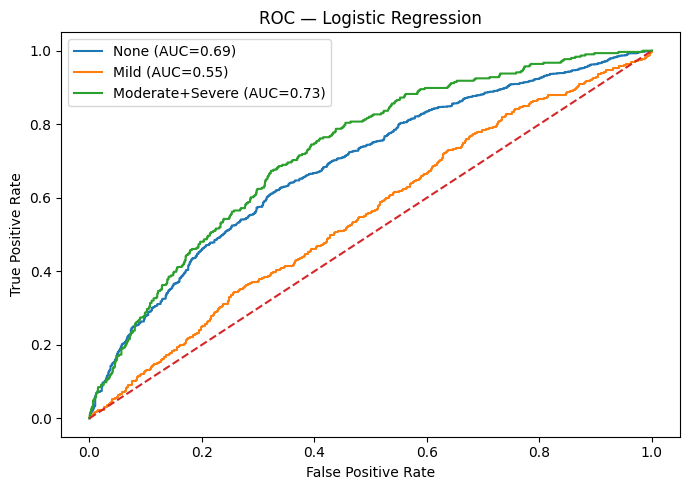

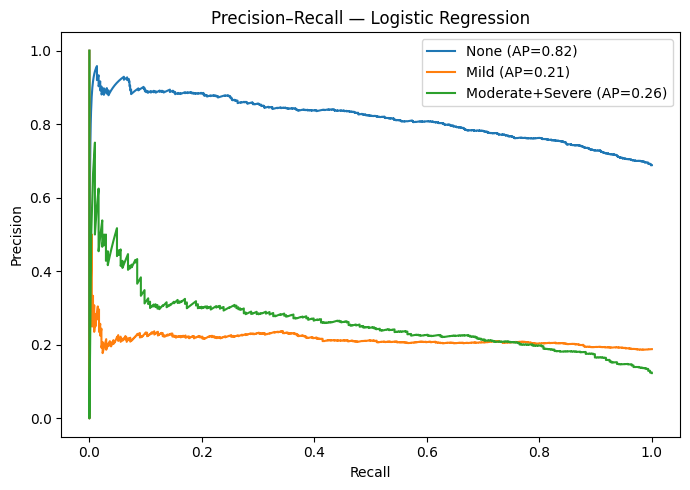

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr_model_path = CLASSIFICATION_DIR / "logistic_regression.joblib"

if lr_model_path.exists():
    best_lr = joblib.load(lr_model_path)
    print("Loaded cached Logistic Regression.")
else:
    lr_search = GridSearchCV(
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE,
        ),
        param_grid={
            "C": [0.001, 0.01, 0.1, 1, 10, 100],
            "solver": ["lbfgs", "saga"],
        },
        cv=5,
        scoring="f1_macro",
        n_jobs=-1,
        refit=True,
    )
    lr_search.fit(X_train_scaled, y_train)
    best_lr = lr_search.best_estimator_
    classification_best_params["Logistic Regression"] = lr_search.best_params_
    joblib.dump(best_lr, lr_model_path)

print("Best Logistic Regression params:", best_lr.get_params()["C"], best_lr.get_params()["solver"])
classification_models["Logistic Regression"] = best_lr
lr_row, lr_pred, lr_prob = show_classification_result("Logistic Regression", best_lr)
plot_multiclass_roc("Logistic Regression", y_test, lr_prob)
plot_multiclass_pr("Logistic Regression", y_test, lr_prob)

## 5. Support Vector Machines

Four kernels are evaluated with `class_weight="balanced"`:

- Linear
- RBF
- Polynomial
- Sigmoid


Loaded cached SVM Linear.

SVM Linear params: {'C': 0.01, 'break_ties': False, 'cache_size': 200, 'class_weight': 'balanced', 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}

SVM Linear
                 precision    recall  f1-score   support

           None     0.7957    0.6256    0.7005      1712
           Mild     0.2096    0.2244    0.2167       468
Moderate+Severe     0.2347    0.4902    0.3175       306

       accuracy                         0.5334      2486
      macro avg     0.4133    0.4467    0.4115      2486
   weighted avg     0.6163    0.5334    0.5622      2486



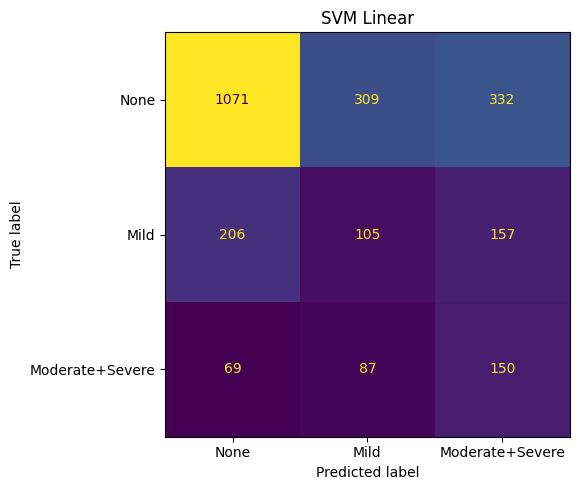

Loaded cached SVM RBF.

SVM RBF params: {'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': 'balanced', 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}

SVM RBF
                 precision    recall  f1-score   support

           None     0.7988    0.6192    0.6976      1712
           Mild     0.2331    0.3162    0.2684       468
Moderate+Severe     0.2252    0.3856    0.2843       306

       accuracy                         0.5334      2486
      macro avg     0.4190    0.4403    0.4168      2486
   weighted avg     0.6217    0.5334    0.5659      2486



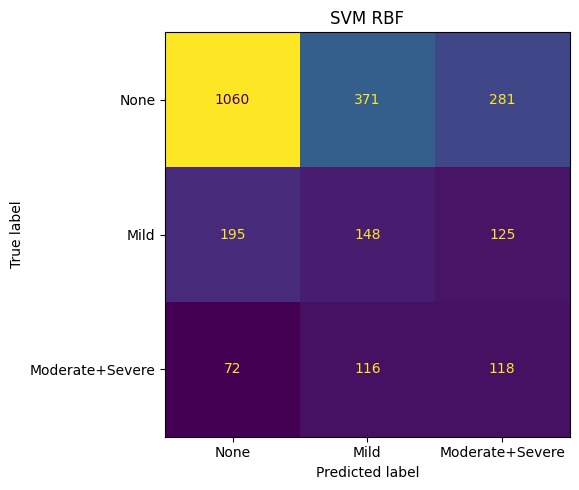

Loaded cached SVM Polynomial.

SVM Polynomial params: {'C': 0.1, 'break_ties': False, 'cache_size': 200, 'class_weight': 'balanced', 'coef0': 1.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'poly', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}

SVM Polynomial
                 precision    recall  f1-score   support

           None     0.7919    0.6379    0.7066      1712
           Mild     0.2286    0.2799    0.2517       468
Moderate+Severe     0.2266    0.3954    0.2881       306

       accuracy                         0.5406      2486
      macro avg     0.4157    0.4377    0.4154      2486
   weighted avg     0.6163    0.5406    0.5694      2486



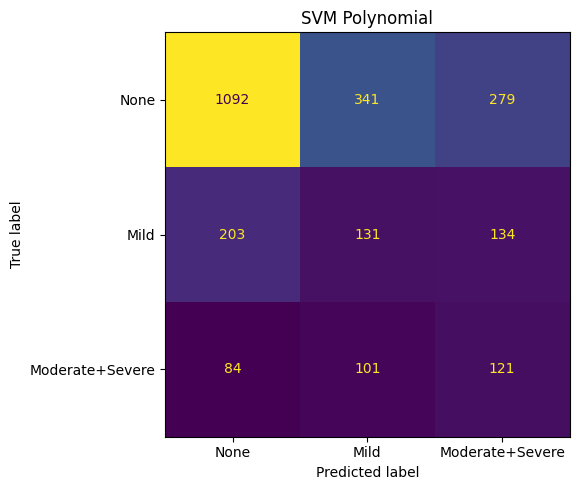

Loaded cached SVM Sigmoid.

SVM Sigmoid params: {'C': 0.1, 'break_ties': False, 'cache_size': 200, 'class_weight': 'balanced', 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'auto', 'kernel': 'sigmoid', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}

SVM Sigmoid
                 precision    recall  f1-score   support

           None     0.7825    0.6075    0.6840      1712
           Mild     0.1776    0.1389    0.1559       468
Moderate+Severe     0.1820    0.4706    0.2625       306

       accuracy                         0.5024      2486
      macro avg     0.3807    0.4057    0.3675      2486
   weighted avg     0.5947    0.5024    0.5327      2486



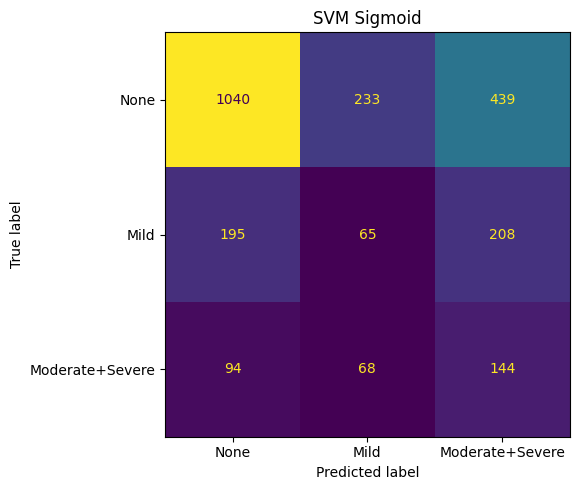

In [7]:
from sklearn.svm import SVC

svm_specs = {
    "SVM Linear": {
        "kernel": "linear",
        "grid": {"C": [0.001, 0.01, 0.1, 1, 10, 100]},
    },
    "SVM RBF": {
        "kernel": "rbf",
        "grid": {
            "C": [0.1, 1, 10],
            "gamma": ["scale", "auto"],
        },
    },
    "SVM Polynomial": {
        "kernel": "poly",
        "grid": {
            "C": [0.1, 1, 10],
            "gamma": ["scale", "auto"],
            "degree": [2, 3],
            "coef0": [0.0, 1.0],
        },
    },
    "SVM Sigmoid": {
        "kernel": "sigmoid",
        "grid": {
            "C": [0.1, 1, 10],
            "gamma": ["scale", "auto"],
            "coef0": [0.0, 1.0],
        },
    },
}

svm_probabilities = {}

for model_name, spec in svm_specs.items():
    model_path = CLASSIFICATION_DIR / f"{model_name.lower().replace(' ', '_')}.joblib"

    if model_path.exists():
        best_svm = joblib.load(model_path)
        print(f"Loaded cached {model_name}.")
    else:
        search = GridSearchCV(
            SVC(
                kernel=spec["kernel"],
                class_weight="balanced",
                probability=True,
                random_state=RANDOM_STATE,
            ),
            param_grid=spec["grid"],
            cv=5,
            scoring="f1_macro",
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_train_scaled, y_train)
        best_svm = search.best_estimator_
        classification_best_params[model_name] = search.best_params_
        joblib.dump(best_svm, model_path)

    classification_models[model_name] = best_svm
    print(f"\n{model_name} params:", best_svm.get_params())
    row, pred, prob = show_classification_result(model_name, best_svm)
    svm_probabilities[model_name] = prob

In [8]:
# Compact comparison of the four SVM variants.
svm_result_table = (
    pd.DataFrame(classification_results)
    .loc[lambda d: d["model"].str.startswith("SVM")]
    [
        [
            "model",
            "accuracy",
            "macro_f1",
            "class_0_f1",
            "class_1_f1",
            "class_2_f1",
        ]
    ]
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(svm_result_table.round(3))

,model,accuracy,macro_f1,class_0_f1,class_1_f1,class_2_f1
0,SVM RBF,0.533,0.417,0.698,0.268,0.284
1,SVM Polynomial,0.541,0.415,0.707,0.252,0.288
2,SVM Linear,0.533,0.412,0.700,0.217,0.317
3,SVM Sigmoid,0.502,0.367,0.684,0.156,0.263


## 6. Neural Networks

### 6.1 scikit-learn MLP

The MLP search space is retained from the three-class:

- several hidden-layer layouts;
- `alpha ∈ {0.1, 0.01, 0.001}`;
- learning rate `0.01`, `0.001`, `0.0001`;
- `tanh` or `relu`;
- early stopping with tolerance `1e-4` and patience 20.

The unweighted MLP is kept because it illustrates the majority-class collapse.

Loaded cached MLP.
MLP parameters: {'activation': 'tanh', 'alpha': 0.01, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': True, 'epsilon': 1e-08, 'hidden_layer_sizes': (32, 16), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 1000, 'momentum': 0.9, 'n_iter_no_change': 20, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}
MLP epochs: 32

MLP
===
                 precision    recall  f1-score   support

           None     0.7065    0.9574    0.8130      1712
           Mild     0.1875    0.0256    0.0451       468
Moderate+Severe     0.3922    0.1307    0.1961       306

       accuracy                         0.6802      2486
      macro avg     0.4287    0.3712    0.3514      2486
   weighted avg     0.5701    0.6802    0.5925      2486



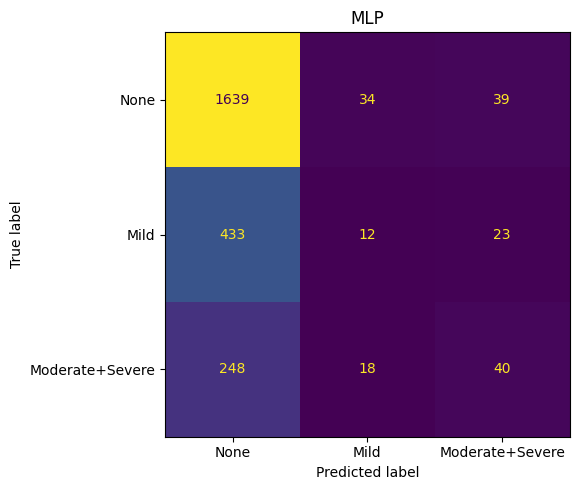

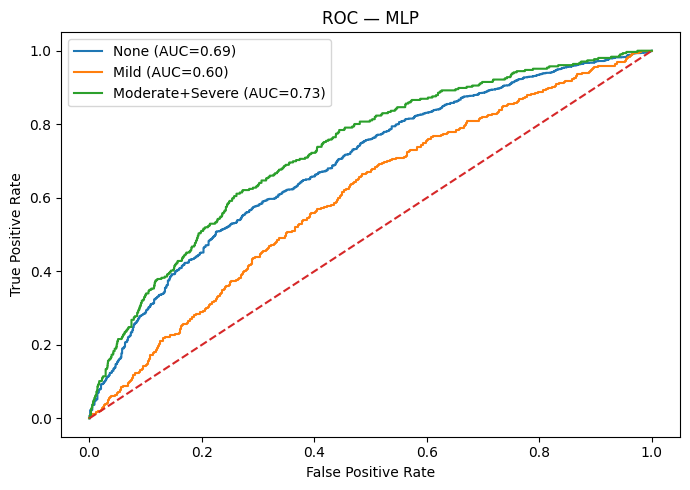

In [9]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV

mlp_model_path = CLASSIFICATION_DIR / "mlp_classifier.joblib"

if mlp_model_path.exists():
    best_mlp = joblib.load(mlp_model_path)
    print("Loaded cached MLP.")
else:
    mlp_search = RandomizedSearchCV(
        MLPClassifier(
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            tol=1e-4,
            random_state=RANDOM_STATE,
        ),
        param_distributions={
            "hidden_layer_sizes": [
                (256, 128, 64),
                (128, 64, 32),
                (64, 32),
                (32, 16),
                (16, 8),
                (16,),
                (8,),
            ],
            "alpha": [0.1, 0.01, 0.001],
            "learning_rate_init": [0.01, 0.001, 0.0001],
            "activation": ["tanh", "relu"],
        },
        n_iter=15,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
    )
    mlp_search.fit(X_train_scaled, y_train)
    best_mlp = mlp_search.best_estimator_
    classification_best_params["MLP"] = mlp_search.best_params_
    joblib.dump(best_mlp, mlp_model_path)

classification_models["MLP"] = best_mlp
print("MLP parameters:", best_mlp.get_params())
print("MLP epochs:", best_mlp.n_iter_)
mlp_row, mlp_pred, mlp_prob = show_classification_result("MLP", best_mlp)
plot_multiclass_roc("MLP", y_test, mlp_prob)

### 6.2 Cost-sensitive PyTorch DNN

- the original 70% training partition is split again into DNN-train and DNN-validation;
- the 30% test partition remains untouched until the final evaluation;
- class weights are computed only from the DNN training subset;
- Dropout, weight decay and early stopping are preserved.

In [10]:
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    from sklearn.utils.class_weight import compute_class_weight
except ImportError as exc:
    raise ImportError(
        "PyTorch is required for the DNN section. Install it with pip install torch."
    ) from exc

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

dnn_train_pos, dnn_val_pos = train_test_split(
    np.arange(len(X_train_scaled)),
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=y_train.to_numpy(),
)

X_dnn_train = X_train_scaled.iloc[dnn_train_pos]
X_dnn_val = X_train_scaled.iloc[dnn_val_pos]
y_dnn_train = y_train.iloc[dnn_train_pos]
y_dnn_val = y_train.iloc[dnn_val_pos]

print("DNN train:", X_dnn_train.shape)
print("DNN validation:", X_dnn_val.shape)
print("Final test:", X_test_scaled.shape)

DNN train: (5220, 28)
DNN validation: (580, 28)
Final test: (2486, 28)


In [11]:
class CostSensitiveDNN(nn.Module):
    def __init__(self, input_dim, num_classes=3, batch_norm=False):
        super().__init__()
        self.batch_norm = batch_norm

        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.out = nn.Linear(32, num_classes)

        if batch_norm:
            self.bn1 = nn.BatchNorm1d(128)
            self.bn2 = nn.BatchNorm1d(64)
            self.bn3 = nn.BatchNorm1d(32)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.30)

    def _block(self, x, layer, bn=None):
        x = layer(x)
        if bn is not None:
            x = bn(x)
        x = self.relu(x)
        x = self.dropout(x)
        return x

    def forward(self, x):
        x = self._block(x, self.fc1, self.bn1 if self.batch_norm else None)
        x = self._block(x, self.fc2, self.bn2 if self.batch_norm else None)
        x = self._block(x, self.fc3, self.bn3 if self.batch_norm else None)
        return self.out(x)


def train_torch_classifier(
    *,
    model_name,
    batch_norm=False,
    X_train_df=X_dnn_train,
    y_train_series=y_dnn_train,
    X_val_df=X_dnn_val,
    y_val_series=y_dnn_val,
    max_epochs=300,
    patience=30,
    learning_rate=1e-4,
    weight_decay=1e-3,
):
    torch.manual_seed(RANDOM_STATE)

    X_tr_t = torch.tensor(X_train_df.to_numpy(dtype=np.float32))
    y_tr_t = torch.tensor(y_train_series.to_numpy(dtype=np.int64))
    X_va_t = torch.tensor(X_val_df.to_numpy(dtype=np.float32))
    y_va_t = torch.tensor(y_val_series.to_numpy(dtype=np.int64))

    loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=32,
        shuffle=True,
    )

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1, 2]),
        y=y_train_series.to_numpy(),
    )
    weight_tensor = torch.tensor(class_weights, dtype=torch.float32)

    model = CostSensitiveDNN(
        input_dim=X_train_df.shape[1],
        num_classes=3,
        batch_norm=batch_norm,
    )

    criterion = nn.CrossEntropyLoss(weight=weight_tensor)
    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
    }

    best_val_loss = np.inf
    best_epoch = -1
    patience_counter = 0
    checkpoint_path = CLASSIFICATION_DIR / f"{model_name}.pth"

    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(batch_y)
            correct += (logits.argmax(dim=1) == batch_y).sum().item()
            total += len(batch_y)

        train_loss = running_loss / total
        train_accuracy = correct / total

        model.eval()
        with torch.no_grad():
            val_logits = model(X_va_t)
            val_loss = criterion(val_logits, y_va_t).item()
            val_accuracy = (
                (val_logits.argmax(dim=1) == y_va_t)
                .float()
                .mean()
                .item()
            )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    model.load_state_dict(
        torch.load(checkpoint_path, weights_only=True)
    )
    model.eval()

    return model, history, best_epoch, epoch, checkpoint_path

In [12]:
dnn_model, dnn_history, dnn_best_epoch, dnn_stop_epoch, dnn_checkpoint = train_torch_classifier(
    model_name="cost_sensitive_dnn",
    batch_norm=False,
)

X_test_t = torch.tensor(X_test_scaled.to_numpy(dtype=np.float32))

with torch.no_grad():
    dnn_logits = dnn_model(X_test_t)
    dnn_prob = torch.softmax(dnn_logits, dim=1).numpy()
    dnn_pred = dnn_logits.argmax(dim=1).numpy()

print("Best validation epoch:", dnn_best_epoch + 1)
print("Stopped after epoch:", dnn_stop_epoch + 1)
print(
    classification_report(
        y_test.to_numpy(),
        dnn_pred,
        labels=[0, 1, 2],
        target_names=[CLASS_LABELS[i] for i in [0, 1, 2]],
        digits=4,
        zero_division=0,
    )
)

class TorchWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        X_t = torch.tensor(np.asarray(X, dtype=np.float32))
        with torch.no_grad():
            return self.model(X_t).argmax(dim=1).numpy()
    def predict_proba(self, X):
        X_t = torch.tensor(np.asarray(X, dtype=np.float32))
        with torch.no_grad():
            return torch.softmax(self.model(X_t), dim=1).numpy()

dnn_wrapper = TorchWrapper(dnn_model)
classification_models["PyTorch DNN"] = dnn_wrapper
dnn_row, _, _ = classification_metrics_row(
    "PyTorch DNN",
    dnn_wrapper,
    X_test_scaled,
    y_test,
)

Best validation epoch: 50
Stopped after epoch: 80
                 precision    recall  f1-score   support

           None     0.8138    0.6151    0.7006      1712
           Mild     0.2550    0.2970    0.2744       468
Moderate+Severe     0.2427    0.5131    0.3295       306

       accuracy                         0.5426      2486
      macro avg     0.4372    0.4751    0.4348      2486
   weighted avg     0.6383    0.5426    0.5747      2486



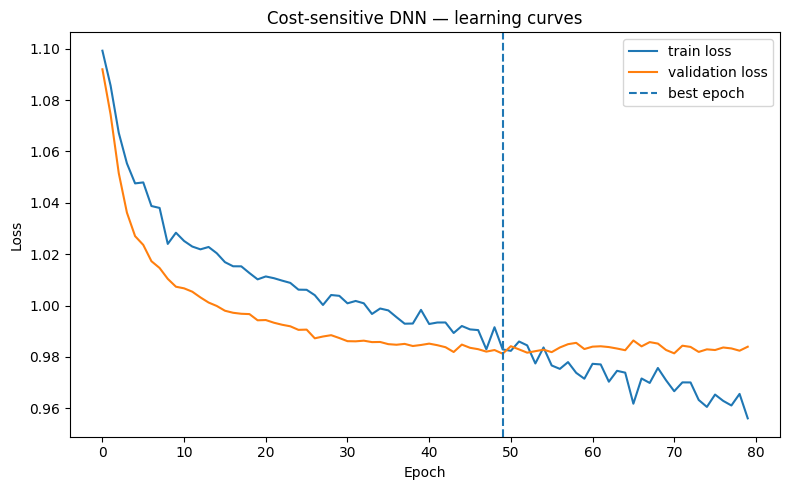

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(dnn_history["train_loss"], label="train loss")
ax.plot(dnn_history["val_loss"], label="validation loss")
ax.axvline(dnn_best_epoch, linestyle="--", label="best epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Cost-sensitive DNN — learning curves")
ax.legend()
plt.tight_layout()
plt.show()

### 6.3 Additional neural-network checks

In [14]:
RUN_OPTIONAL_NN_EXPERIMENTS = True

if RUN_OPTIONAL_NN_EXPERIMENTS:
    # Batch-Normalized version, using the corrected train/validation split.
    bn_model, bn_history, bn_best_epoch, bn_stop_epoch, bn_checkpoint = train_torch_classifier(
        model_name="batchnorm_dnn",
        batch_norm=True,
    )

    bn_wrapper = TorchWrapper(bn_model)
    classification_models["DNN + BatchNorm"] = bn_wrapper
    bn_row, _, _ = classification_metrics_row(
        "DNN + BatchNorm",
        bn_wrapper,
        X_test_scaled,
        y_test,
    )

    print("BatchNorm best epoch:", bn_best_epoch + 1)
    print("BatchNorm stop epoch:", bn_stop_epoch + 1)

    try:
        from imblearn.over_sampling import SMOTE

        smote = SMOTE(random_state=RANDOM_STATE)
        X_smote, y_smote = smote.fit_resample(X_dnn_train, y_dnn_train)

        # Validation remains original and untouched.
        smote_model, smote_history, smote_best_epoch, smote_stop_epoch, smote_checkpoint = train_torch_classifier(
            model_name="smote_dnn",
            batch_norm=False,
            X_train_df=pd.DataFrame(X_smote, columns=feature_names),
            y_train_series=pd.Series(y_smote),
            X_val_df=X_dnn_val,
            y_val_series=y_dnn_val,
        )

        smote_wrapper = TorchWrapper(smote_model)
        classification_models["DNN + SMOTE"] = smote_wrapper
        smote_row, _, _ = classification_metrics_row(
            "DNN + SMOTE",
            smote_wrapper,
            X_test_scaled,
            y_test,
        )

        print("SMOTE training distribution:", Counter(y_smote))
    except ImportError:
        warnings.warn("imbalanced-learn not available: SMOTE NN experiment skipped.")

BatchNorm best epoch: 48
BatchNorm stop epoch: 78
SMOTE training distribution: Counter({0: 3594, 2: 3594, 1: 3594})


## 7. Ensemble Methods — Random Forest and Extra Trees

Both tree ensembles use `class_weight="balanced"` and macro-F1 for tuning.

We identified Random Forest as the best overall class-balanced classifier.

Loaded cached Random Forest.
Random Forest params: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 20, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Random Forest
                 precision    recall  f1-score   support

           None     0.8148    0.6577    0.7279      1712
           Mild     0.2661    0.3440    0.3001       468
Moderate+Severe     0.2405    0.3922    0.2981       306

       accuracy                         0.5660      2486
      macro avg     0.4405    0.4646    0.4420      2486
   weighted avg     0.6408    0.5660    0.5944      2486



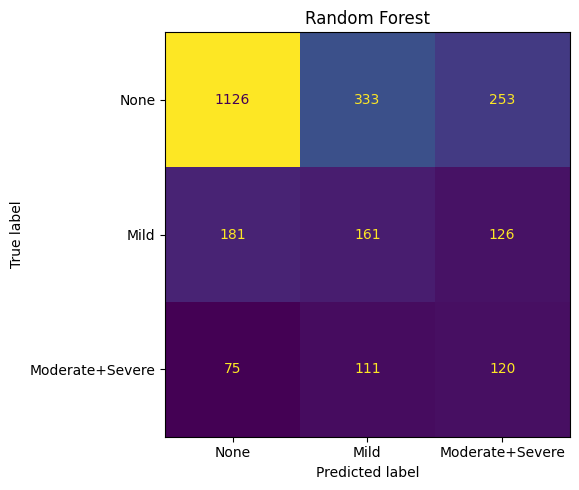

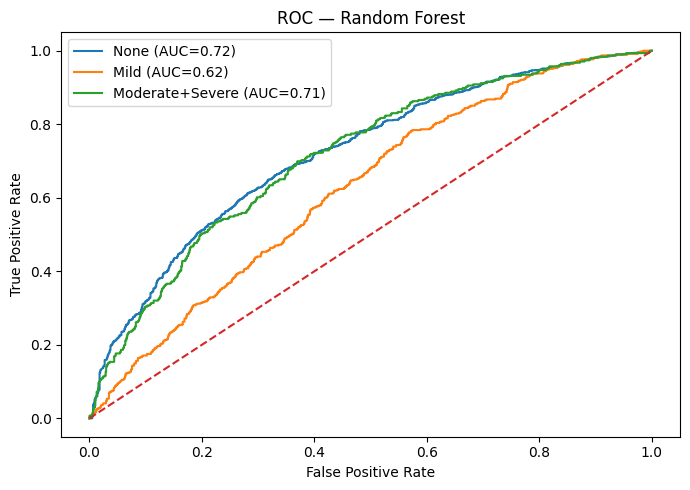

In [10]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_path = CLASSIFICATION_DIR / "random_forest.joblib"

if rf_path.exists():
    best_rf = joblib.load(rf_path)
    print("Loaded cached Random Forest.")
else:
    rf_search = GridSearchCV(
        RandomForestClassifier(
            criterion="gini",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        param_grid={
            "n_estimators": [200, 300],
            "max_depth": [5, 10, 20, None],
            "min_samples_leaf": [1, 2, 5, 20, 50],
            "min_samples_split": [2, 5, 20, 50, 100],
        },
        cv=5,
        scoring="f1_macro",
        n_jobs=-1,
        refit=True,
    )
    rf_search.fit(X_train_scaled, y_train)
    best_rf = rf_search.best_estimator_
    classification_best_params["Random Forest"] = rf_search.best_params_
    joblib.dump(best_rf, rf_path)

classification_models["Random Forest"] = best_rf
print("Random Forest params:", best_rf.get_params())
rf_row, rf_pred, rf_prob = show_classification_result("Random Forest", best_rf)
plot_multiclass_roc("Random Forest", y_test, rf_prob)

Loaded cached Extra Trees.
Extra Trees params: {'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Extra Trees
                 precision    recall  f1-score   support

           None     0.7709    0.7687    0.7698      1712
           Mild     0.2727    0.2115    0.2383       468
Moderate+Severe     0.2620    0.3562    0.3019       306

       accuracy                         0.6130      2486
      macro avg     0.4352    0.4455    0.4367      2486
   weighted avg     0.6145    0.6130    0.6122      2486



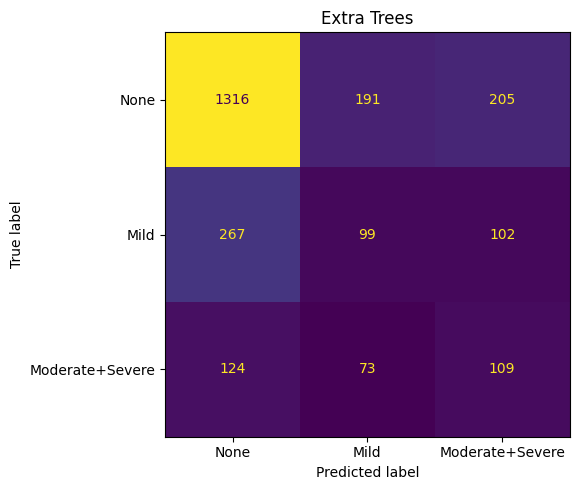

In [11]:
et_path = CLASSIFICATION_DIR / "extra_trees.joblib"

if et_path.exists():
    best_et = joblib.load(et_path)
    print("Loaded cached Extra Trees.")
else:
    et_search = RandomizedSearchCV(
        ExtraTreesClassifier(
            criterion="gini",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        param_distributions={
            "n_estimators": [100, 200, 300],
            "max_depth": [10, 20, 30, None],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 5, 10],
        },
        n_iter=15,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
    )
    et_search.fit(X_train_scaled, y_train)
    best_et = et_search.best_estimator_
    classification_best_params["Extra Trees"] = et_search.best_params_
    joblib.dump(best_et, et_path)

classification_models["Extra Trees"] = best_et
print("Extra Trees params:", best_et.get_params())
et_row, et_pred, et_prob = show_classification_result("Extra Trees", best_et)

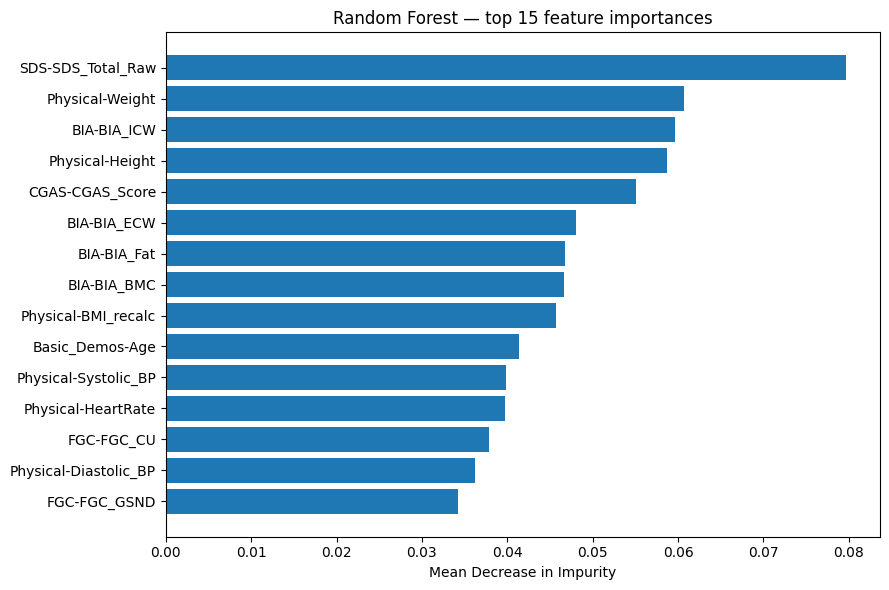

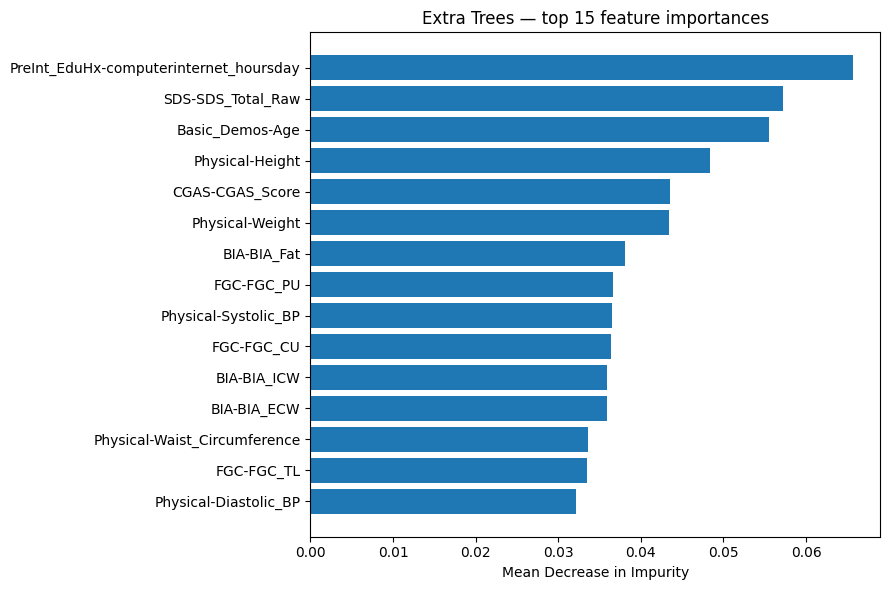

,feature,importance
22,SDS-SDS_Total_Raw,0.079678
5,Physical-Weight,0.060662
21,BIA-BIA_ICW,0.059591
4,Physical-Height,0.058676
3,CGAS-CGAS_Score,0.055069
18,BIA-BIA_ECW,0.048058
19,BIA-BIA_Fat,0.046712
17,BIA-BIA_BMC,0.046631
0,Physical-BMI_recalc,0.045683
1,Basic_Demos-Age,0.041420


In [12]:
def plot_tree_feature_importance(model_name, model, top_n=15):
    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .head(top_n)
        .sort_values("importance")
    )

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(importance_df["feature"], importance_df["importance"])
    ax.set_xlabel("Mean Decrease in Impurity")
    ax.set_title(f"{model_name} — top {top_n} feature importances")
    plt.tight_layout()
    plt.show()

    return importance_df.sort_values("importance", ascending=False)

rf_feature_importance = plot_tree_feature_importance("Random Forest", best_rf)
et_feature_importance = plot_tree_feature_importance("Extra Trees", best_et)

display(rf_feature_importance)

## 8. Gradient Boosting — XGBoost

The search below is the 15-configuration RandomizedSearch used in the three-class analysis.

Loaded cached XGBoost.
XGBoost params: {'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'mlogloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0.2, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.2, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 7, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 300, 'n_jobs': 1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0, 'reg_lambda': 1, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.6, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}

XGBoost
                 precision    recall  f1-s

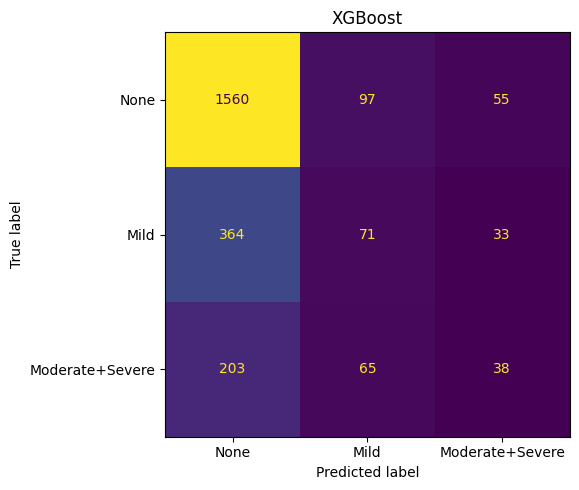

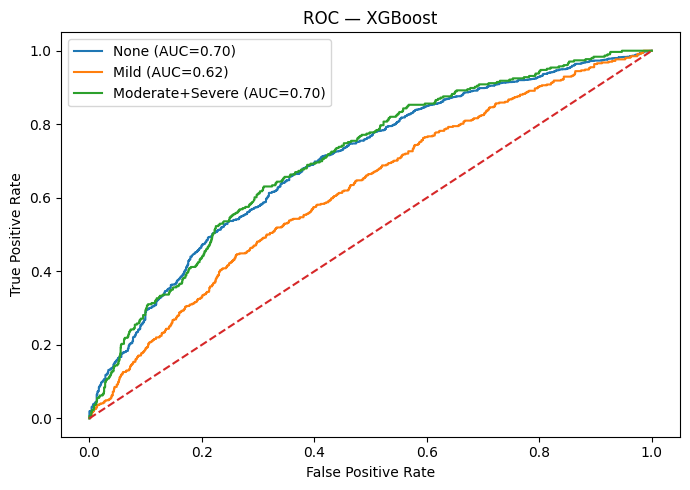

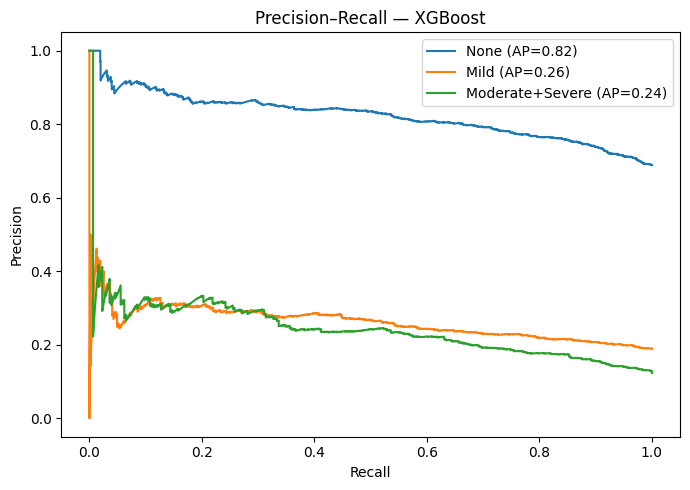

In [13]:
import xgboost as xgb

xgb_path = CLASSIFICATION_DIR / "xgboost.joblib"

if xgb_path.exists():
    best_xgb = joblib.load(xgb_path)
    print("Loaded cached XGBoost.")

else:
    xgb_search = RandomizedSearchCV(
        xgb.XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_jobs=1,      # changed
        ),

        param_distributions={
            "n_estimators": [50, 100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "max_depth": [3, 5, 7, 9],
            "subsample": [0.6, 0.8, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0],
            "gamma": [0, 0.1, 0.2, 0.3],
            "reg_lambda": [0, 1, 10],
            "reg_alpha": [0, 0.1, 1],
        },

        n_iter=15,
        cv=3,
        scoring="f1_macro",
        n_jobs=1,         # changed
        random_state=RANDOM_STATE,
        refit=True,
    )

    xgb_search.fit(
        X_train_scaled,
        y_train
    )

    best_xgb = xgb_search.best_estimator_

    classification_best_params[
        "XGBoost"
    ] = xgb_search.best_params_

    joblib.dump(
        best_xgb,
        xgb_path
    )


classification_models[
    "XGBoost"
] = best_xgb

print(
    "XGBoost params:",
    best_xgb.get_params()
)

xgb_row, xgb_pred, xgb_prob = (
    show_classification_result(
        "XGBoost",
        best_xgb
    )
)

plot_multiclass_roc(
    "XGBoost",
    y_test,
    xgb_prob
)

plot_multiclass_pr(
    "XGBoost",
    y_test,
    xgb_prob
)

,feature,importance
4,Physical-Height,0.045148
23,PreInt_EduHx-computerinternet_hoursday,0.042386
22,SDS-SDS_Total_Raw,0.040033
15,FGC-FGC_TL,0.038226
2,Basic_Demos-Sex,0.037880
18,BIA-BIA_ECW,0.037608
10,Fitness_Endurance-Max_Stage,0.037484
14,FGC-FGC_PU,0.037306
11,FGC-FGC_CU,0.037225
3,CGAS-CGAS_Score,0.036881


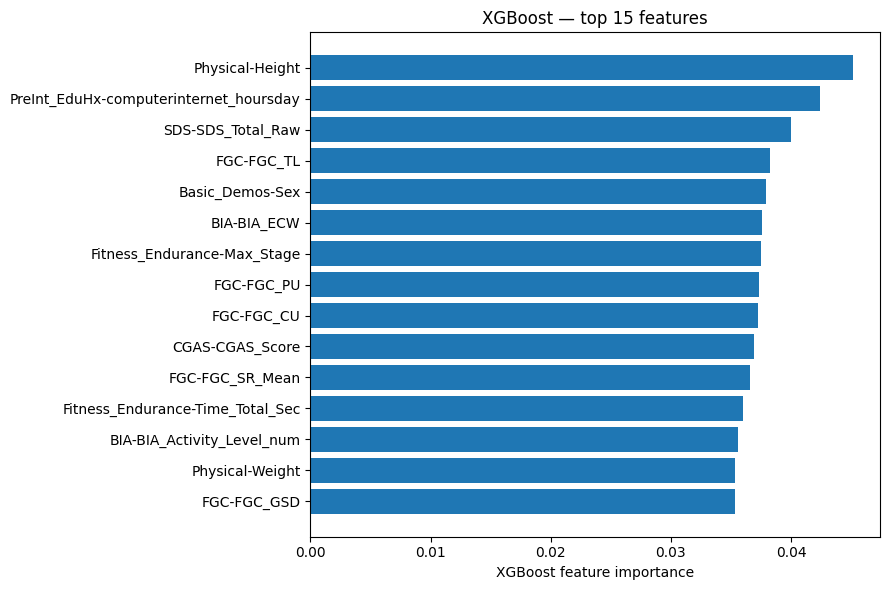

In [14]:
xgb_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": best_xgb.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .head(15)
)

display(xgb_importance)

fig, ax = plt.subplots(figsize=(9, 6))
plot_df = xgb_importance.sort_values("importance")
ax.barh(plot_df["feature"], plot_df["importance"])
ax.set_xlabel("XGBoost feature importance")
ax.set_title("XGBoost — top 15 features")
plt.tight_layout()
plt.show()

## 9. Final classification comparison

In [15]:
classification_results_df = (
    pd.DataFrame(classification_results)
    .drop_duplicates(subset=["model"], keep="last")
    .sort_values(["macro_f1", "accuracy"], ascending=[False, False])
    .reset_index(drop=True)
)

display(
    classification_results_df[
        [
            "model",
            "accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "class_0_f1",
            "class_1_f1",
            "class_2_f1",
        ]
    ].round(3)
)

best_current_classifier = classification_results_df.iloc[0]

print(
    "Best current classifier by macro-F1:",
    best_current_classifier["model"],
    f"(macro-F1={best_current_classifier['macro_f1']:.3f})",
)

,model,accuracy,macro_precision,macro_recall,macro_f1,class_0_f1,class_1_f1,class_2_f1
0,Random Forest,0.566,0.440,0.465,0.442,0.728,0.300,0.298
1,Extra Trees,0.613,0.435,0.445,0.437,0.770,0.238,0.302
2,SVM RBF,0.533,0.419,0.440,0.417,0.698,0.268,0.284
3,SVM Polynomial,0.541,0.416,0.438,0.415,0.707,0.252,0.288
4,SVM Linear,0.533,0.413,0.447,0.412,0.700,0.217,0.317
5,Logistic Regression,0.526,0.416,0.450,0.412,0.692,0.231,0.312
6,XGBoost,0.671,0.447,0.396,0.397,0.813,0.203,0.176
7,SVM Sigmoid,0.502,0.381,0.406,0.367,0.684,0.156,0.263
8,MLP,0.680,0.429,0.371,0.351,0.813,0.045,0.196


Best current classifier by macro-F1: Random Forest (macro-F1=0.442)


In [16]:
CLASSIFICATION_RESULTS_PATH = CLASSIFICATION_DIR / "classification_results.csv"
CLASSIFICATION_PARAMS_PATH = CLASSIFICATION_DIR / "classification_best_params.json"

classification_results_df.to_csv(CLASSIFICATION_RESULTS_PATH, index=False)

with open(CLASSIFICATION_PARAMS_PATH, "w", encoding="utf-8") as f:
    json.dump(classification_best_params, f, indent=2, default=str)

print("Saved:", CLASSIFICATION_RESULTS_PATH)
print("Saved:", CLASSIFICATION_PARAMS_PATH)

Saved: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module2/classification/classification_results.csv
Saved: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module2/classification/classification_best_params.json


# Explainability

## 10. Reuse the final XGBoost classifier

The final XAI analysis explains the **XGBoost classifier**:

- same three-class target;
- same 70/30 split;
- same 28 predictors;
- same StandardScaler;
- same selected XGBoost model.

In [17]:
bb = best_xgb

xai_pred = bb.predict(X_test_scaled)
xai_prob = bb.predict_proba(X_test_scaled)

print("XAI black-box accuracy:", accuracy_score(y_test, xai_pred))
print("XAI black-box macro-F1:", f1_score(y_test, xai_pred, average="macro"))

XAI black-box accuracy: 0.67135961383749
XAI black-box macro-F1: 0.3970684433084988


## 11. XGBoost global gain importance

In [18]:
booster = bb.get_booster()
gain_dict = booster.get_score(importance_type="gain")

mapped_gain = {}

for key, value in gain_dict.items():
    if key.startswith("f") and key[1:].isdigit():
        idx = int(key[1:])
        mapped_gain[feature_names[idx]] = value
    else:
        mapped_gain[key] = value

for feature in feature_names:
    mapped_gain.setdefault(feature, 0.0)

xgb_gain_importance = (
    pd.DataFrame({
        "feature": list(mapped_gain.keys()),
        "gain": list(mapped_gain.values()),
    })
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)

display(xgb_gain_importance.head(20).round(3))

xgb_gain_importance.to_csv(
    XAI_DIR / "xgboost_gain_importance.csv",
    index=False,
)

,feature,gain
0,Physical-Height,1.188
1,PreInt_EduHx-computerinternet_hoursday,1.115
2,SDS-SDS_Total_Raw,1.053
3,FGC-FGC_TL,1.006
4,Basic_Demos-Sex,0.997
5,BIA-BIA_ECW,0.989
6,Fitness_Endurance-Max_Stage,0.986
7,FGC-FGC_PU,0.981
8,FGC-FGC_CU,0.979
9,CGAS-CGAS_Score,0.970


## 12. SHAP — global and local explanations

SHAP is the primary global/local explanation method.  
For the multiclass XGBoost model, one SHAP contribution matrix is obtained for each class.

In [19]:
try:
    import shap
except ImportError as exc:
    raise ImportError("Install SHAP with: pip install shap") from exc

shap_explainer = shap.TreeExplainer(bb)
raw_shap = shap_explainer.shap_values(X_test_scaled)

if isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 3:
    shap_per_class = [
        raw_shap[:, :, cls]
        for cls in range(raw_shap.shape[2])
    ]
else:
    shap_per_class = raw_shap

print("SHAP classes:", len(shap_per_class))
print("SHAP shape per class:", shap_per_class[0].shape)

SHAP classes: 3
SHAP shape per class: (2486, 28)


,feature,mean_abs_shap,class_name
0,SDS-SDS_Total_Raw,0.350320,None
1,CGAS-CGAS_Score,0.260226,None
2,Physical-Height,0.197765,None
3,PreInt_EduHx-computerinternet_hoursday,0.190983,None
4,Basic_Demos-Age,0.151294,None
5,FGC-FGC_CU,0.137031,None
6,Physical-Systolic_BP,0.123948,None
7,BIA-BIA_ECW,0.120258,None
8,BIA-BIA_ICW,0.117281,None
9,FGC-FGC_GSD,0.117220,None


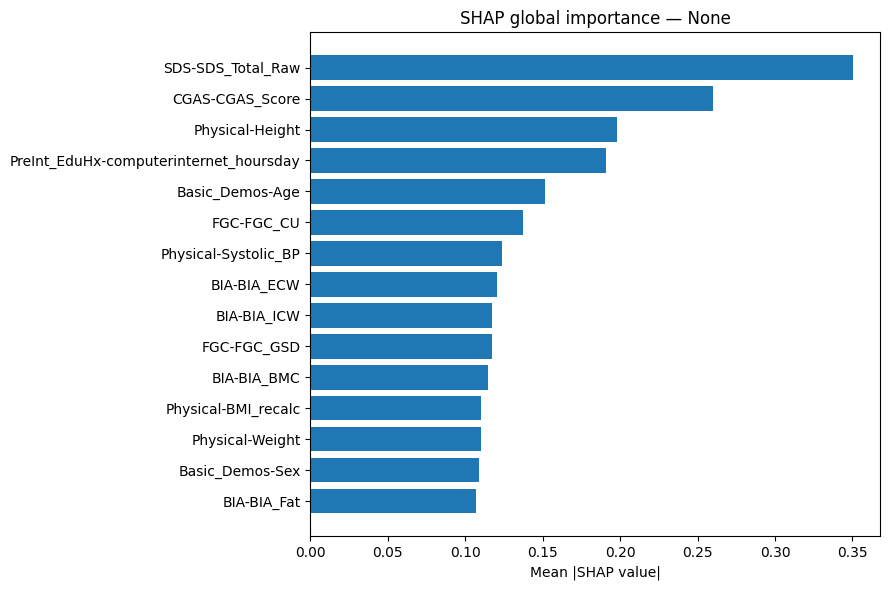

,feature,mean_abs_shap,class_name
0,CGAS-CGAS_Score,0.197301,Mild
1,SDS-SDS_Total_Raw,0.178685,Mild
2,Physical-Systolic_BP,0.160775,Mild
3,BIA-BIA_BMC,0.159058,Mild
4,Physical-Weight,0.156715,Mild
5,Physical-HeartRate,0.155482,Mild
6,FGC-FGC_CU,0.149587,Mild
7,Basic_Demos-Age,0.136685,Mild
8,Physical-Height,0.134846,Mild
9,BIA-BIA_ECW,0.133894,Mild


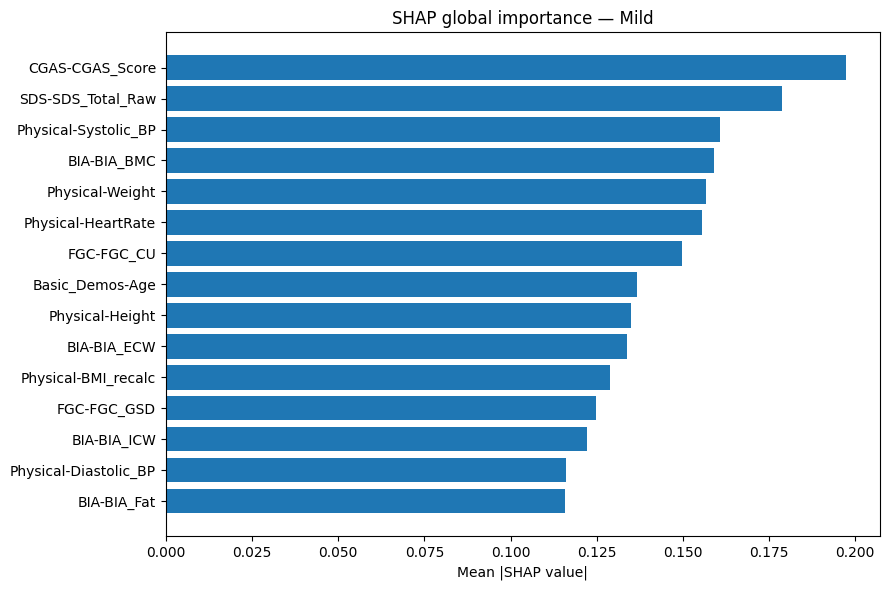

,feature,mean_abs_shap,class_name
0,SDS-SDS_Total_Raw,0.372845,Moderate+Severe
1,CGAS-CGAS_Score,0.279327,Moderate+Severe
2,Basic_Demos-Age,0.233128,Moderate+Severe
3,PreInt_EduHx-computerinternet_hoursday,0.230030,Moderate+Severe
4,Physical-Weight,0.190252,Moderate+Severe
5,Physical-Height,0.185882,Moderate+Severe
6,Physical-BMI_recalc,0.164310,Moderate+Severe
7,BIA-BIA_Fat,0.154721,Moderate+Severe
8,BIA-BIA_BMC,0.153864,Moderate+Severe
9,Fitness_Endurance-Time_Total_Sec,0.151579,Moderate+Severe


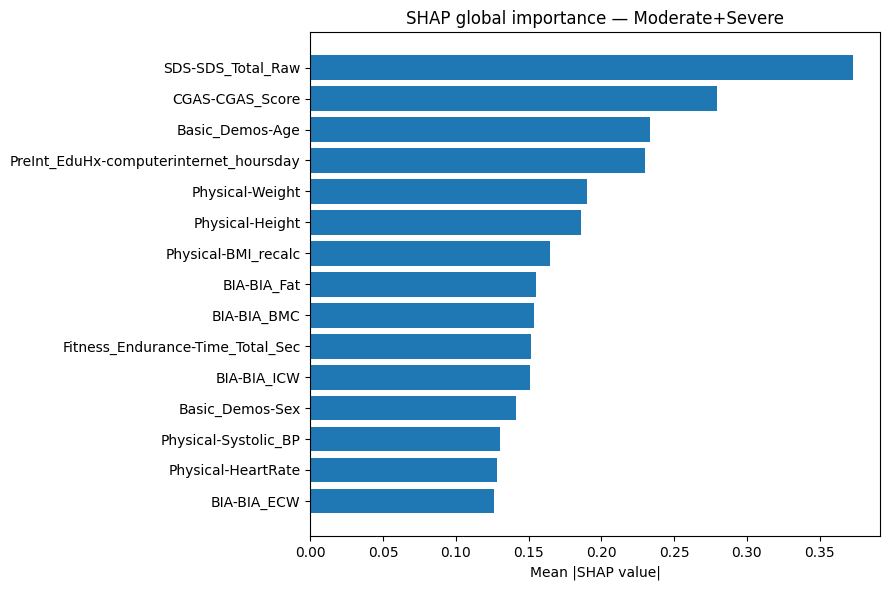

In [20]:
# Global mean |SHAP| ranking for each class.
shap_global_tables = {}

for cls in [0, 1, 2]:
    table = (
        pd.DataFrame({
            "feature": feature_names,
            "mean_abs_shap": np.abs(shap_per_class[cls]).mean(axis=0),
        })
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    shap_global_tables[cls] = table

    display(
        table.head(15)
        .assign(class_name=CLASS_LABELS[cls])
    )

    plot_df = table.head(15).sort_values("mean_abs_shap")
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(plot_df["feature"], plot_df["mean_abs_shap"])
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(f"SHAP global importance — {CLASS_LABELS[cls]}")
    plt.tight_layout()
    plt.show()

SHAP beeswarm — Moderate+Severe


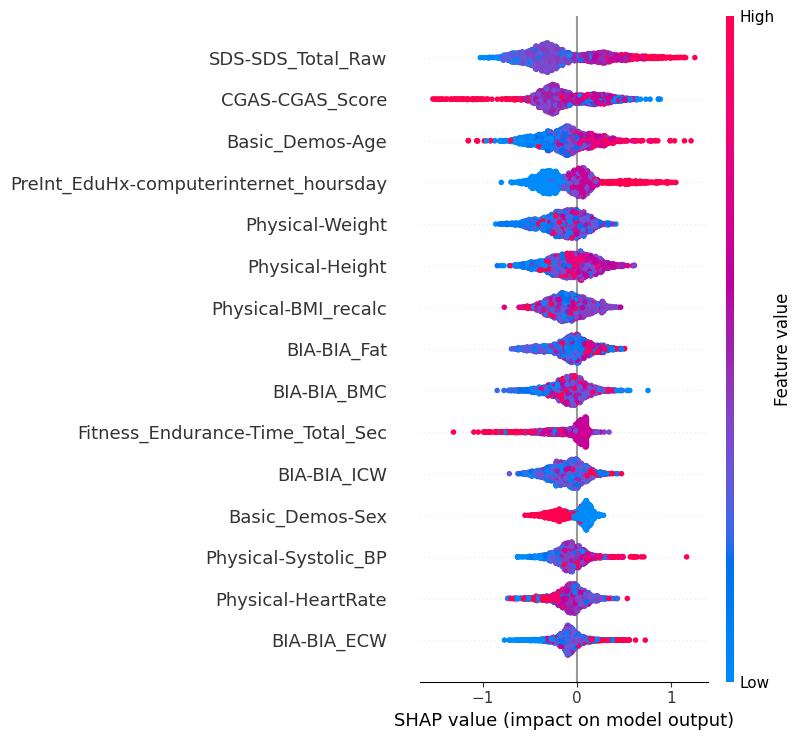

In [21]:
print("SHAP beeswarm — Moderate+Severe")
shap.summary_plot(
    shap_per_class[2],
    X_test_scaled,
    feature_names=feature_names,
    plot_type="dot",
    max_display=15,
    show=True,
)

## 13. Select one correctly classified instance per class

The first correctly classified test observation from each class is chosen. 

In [22]:
y_test_array = y_test.to_numpy()
xai_pred_array = np.asarray(xai_pred)

xai_instance_indices = {}

for cls in [0, 1, 2]:
    correct = np.where(
        (y_test_array == cls)
        & (xai_pred_array == cls)
    )[0]

    if len(correct):
        xai_instance_indices[cls] = int(correct[0])
    else:
        xai_instance_indices[cls] = int(
            np.where(y_test_array == cls)[0][0]
        )

selected_instance_rows = []

for cls in [0, 1, 2]:
    idx = xai_instance_indices[cls]
    pred = int(xai_pred_array[idx])
    prob = xai_prob[idx]

    selected_instance_rows.append({
        "true_class": CLASS_LABELS[cls],
        "test_position": idx,
        "predicted_class": CLASS_LABELS[pred],
        "P_None": prob[0],
        "P_Mild": prob[1],
        "P_Moderate_Severe": prob[2],
    })

selected_instances_df = pd.DataFrame(selected_instance_rows)
display(selected_instances_df.round(3))

selected_instances_df.to_csv(
    XAI_DIR / "selected_xai_instances.csv",
    index=False,
)

,true_class,test_position,predicted_class,P_None,P_Mild,P_Moderate_Severe
0,None,0,None,0.920,0.079,0.001
1,Mild,25,Mild,0.278,0.554,0.168
2,Moderate+Severe,10,Moderate+Severe,0.338,0.305,0.358


## 14. SHAP waterfall explanations

None example — predicted None


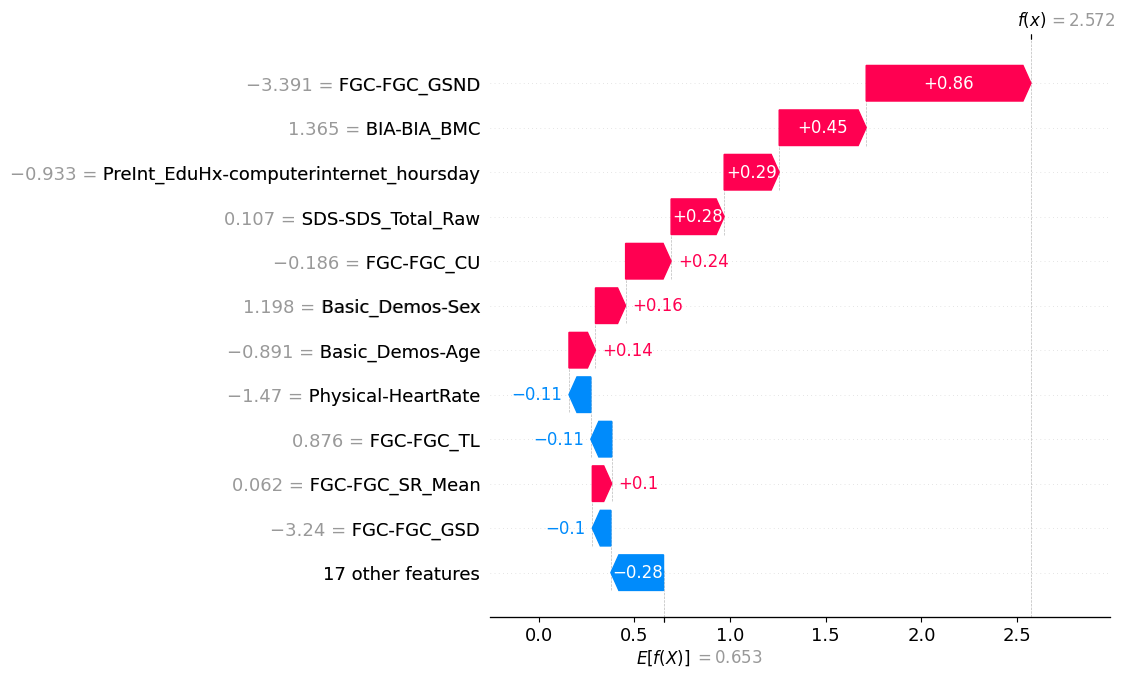

Mild example — predicted Mild


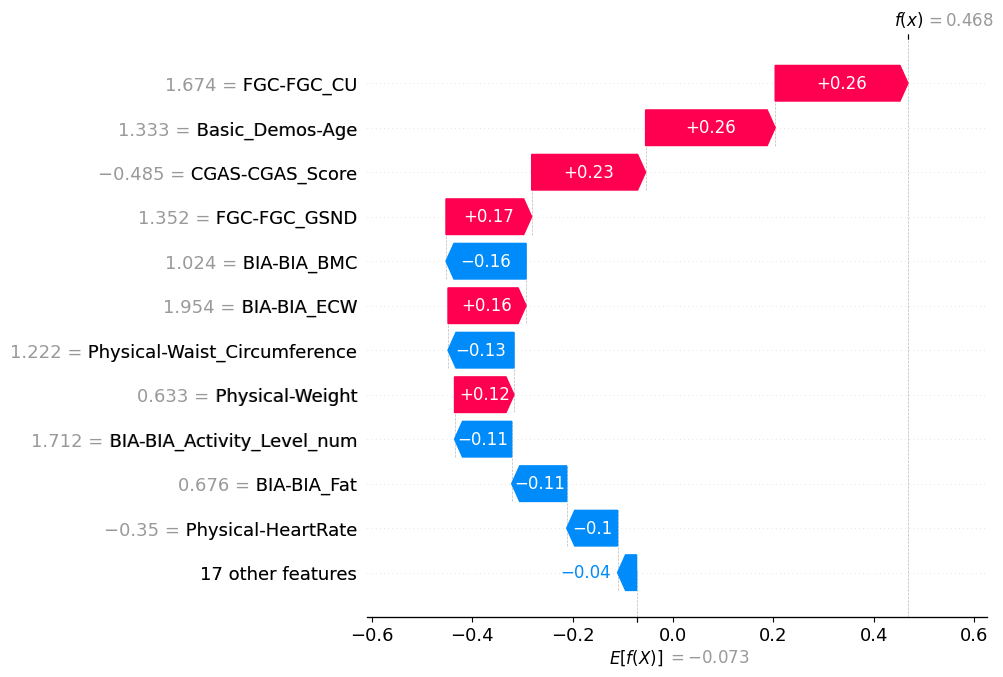

Moderate+Severe example — predicted Moderate+Severe


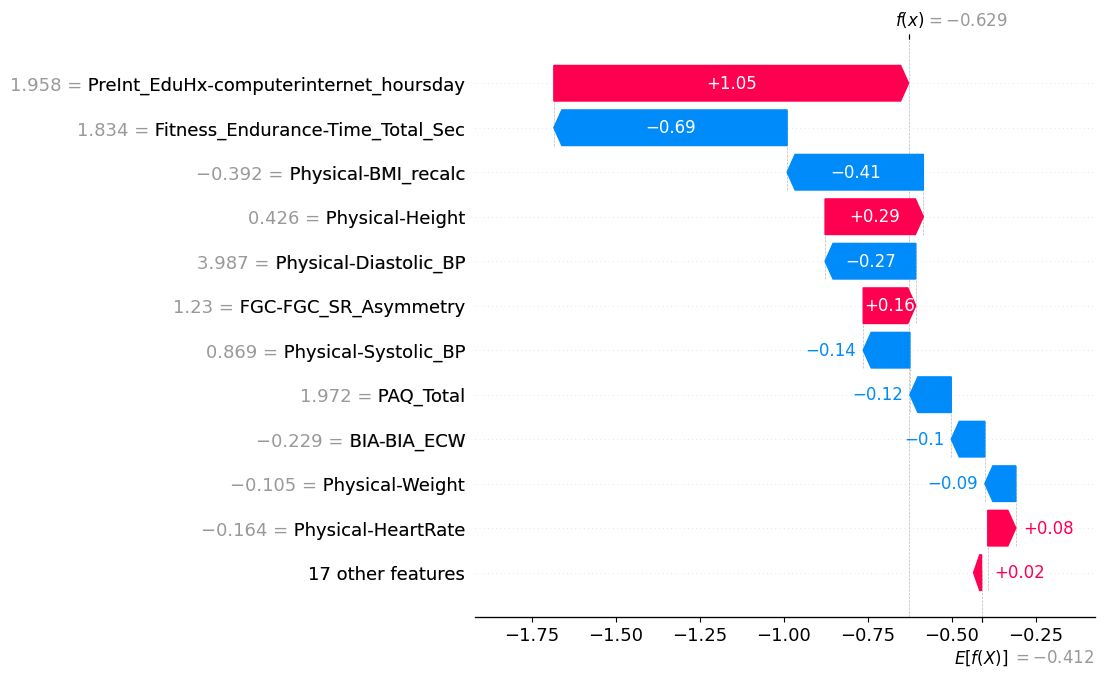

In [23]:
for cls in [0, 1, 2]:
    idx = xai_instance_indices[cls]
    pred = int(xai_pred_array[idx])

    explanation = shap.Explanation(
        values=shap_per_class[pred][idx],
        base_values=shap_explainer.expected_value[pred],
        data=X_test_scaled.iloc[idx].to_numpy(),
        feature_names=feature_names,
    )

    print(
        f"{CLASS_LABELS[cls]} example — predicted {CLASS_LABELS[pred]}"
    )
    shap.plots.waterfall(
        explanation,
        max_display=12,
        show=True,
    )

## 15. SHAP dependence for the high-risk class

Top two SHAP features for Moderate+Severe: ['SDS-SDS_Total_Raw', 'CGAS-CGAS_Score']


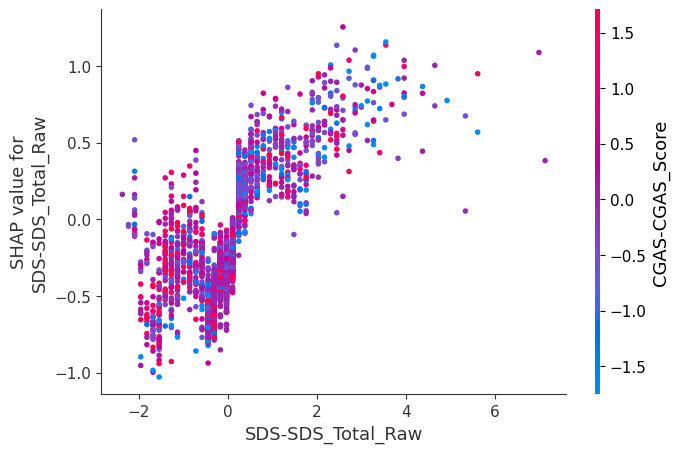

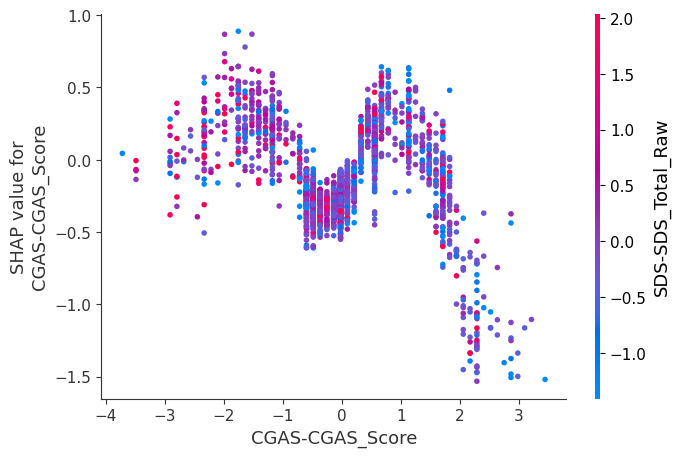

In [24]:
high_risk_mean_abs = np.abs(shap_per_class[2]).mean(axis=0)
top_two_idx = high_risk_mean_abs.argsort()[-2:][::-1]
top_two_features = [feature_names[i] for i in top_two_idx]

print("Top two SHAP features for Moderate+Severe:", top_two_features)

for feature, interaction in [
    (top_two_features[0], top_two_features[1]),
    (top_two_features[1], top_two_features[0]),
]:
    shap.dependence_plot(
        feature,
        shap_per_class[2],
        X_test_scaled,
        feature_names=feature_names,
        interaction_index=interaction,
        show=True,
    )

## 16. LORE — local rules and counterfactuals

In [25]:
def find_lore_directory(project_dir):
    candidates = [
        project_dir / "lore",
        project_dir / "dependencies" / "lore",
        project_dir / "external" / "lore",
    ]

    for candidate in candidates:
        if (
            candidate.exists()
            and (candidate / "lorem.py").exists()
            and (candidate / "util.py").exists()
            and (candidate / "datamanager.py").exists()
        ):
            return candidate

    return None

LORE_DIR = find_lore_directory(PROJECT_DIR)
RUN_LORE = LORE_DIR is not None

print("LORE directory:", LORE_DIR)
print("LORE runnable:", RUN_LORE)

LORE directory: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/lore
LORE runnable: True


In [32]:
%pip install bitarray deap scikit-multilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 635.0/635.0 kB 7.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [deap]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [33]:
if RUN_LORE:
    for module_name in [
        "lorem",
        "util",
        "datamanager",
        "rule",
        "explanation",
        "decision_tree",
        "neighgen",
    ]:
        if module_name in sys.modules:
            del sys.modules[module_name]

    if str(LORE_DIR) in sys.path:
        sys.path.remove(str(LORE_DIR))
    sys.path.insert(0, str(LORE_DIR))

    from lorem import LOREM
    from util import neuclidean
    from datamanager import prepare_dataset
    from rule import apply_counterfactual

    print("LORE imported successfully.")
else:
    print(
        "LORE skipped: the source implementation used by the original project "
        "was not included in the supplied archive."
    )

LORE imported successfully.


In [34]:
if RUN_LORE:
    class_name = "sii"

    df_lore = X_train_scaled.copy()
    df_lore[class_name] = y_train.to_numpy()

    (
        df_prep,
        feature_names_lore,
        class_values_lore,
        numeric_columns_lore,
        rdf_lore,
        real_feature_names_lore,
        features_map_lore,
    ) = prepare_dataset(df_lore, class_name)

    K = rdf_lore[real_feature_names_lore].to_numpy()
    class_values_lore_str = ["0", "1", "2"]

    def bb_predict_lore(X):
        return bb.predict(X).astype(int)

    def bb_predict_proba_lore(X):
        return bb.predict_proba(X)

    lore_explainer = LOREM(
        K,
        bb_predict_lore,
        feature_names_lore,
        class_name,
        class_values_lore_str,
        numeric_columns_lore,
        features_map_lore,
        neigh_type="geneticp",
        categorical_use_prob=True,
        continuous_fun_estimation=False,
        size=1000,
        ocr=0.1,
        ngen=10,
        bb_predict_proba=bb_predict_proba_lore,
        random_state=RANDOM_STATE,
        verbose=True,
    )

    lore_explanations = {}

    for cls in [0, 1, 2]:
        idx = xai_instance_indices[cls]
        x_instance = X_test_scaled.iloc[idx].to_numpy()

        explanation = lore_explainer.explain_instance(
            x_instance,
            samples=500,
            use_weights=True,
            metric=neuclidean,
        )

        lore_explanations[cls] = explanation

        print(f"\nLORE — {CLASS_LABELS[cls]}")
        print("Fidelity:", round(explanation.fidelity, 4))
        print("Rule:", explanation.rule)
        if explanation.crules:
            print("First counterfactual:", explanation.crules[0])
            print("Delta:", [str(d) for d in explanation.deltas[0]])

calculating feature values
generating neighborhood - geneticp
gen	nevals	avg                	min                	max                
0  	250   	0.49665355682373047	0.49665358662605286	0.49665358662605286
1  	215   	0.688996           	0.496654           	0.991644           
2  	208   	0.879312           	0.449256           	0.992506           
3  	222   	0.918152           	0.498844           	0.992506           
4  	218   	0.918729           	0.450632           	0.991873           
5  	209   	0.935847           	0.319303           	0.993132           
6  	207   	0.940101           	0.457635           	0.993132           
7  	209   	0.937217           	0.444292           	0.993306           
8  	211   	0.941273           	0.418791           	0.993306           
9  	202   	0.935684           	0.320846           	0.993306           
10 	214   	0.935464           	0.332282           	0.993306           
gen	nevals	avg	min	max
0  	250   	0.5	0.5	0.5
1  	215   	0.485497	0.165172	0.947142
2 

### 16.1 Domain-aware validation of the high-risk LORE counterfactual

LORE rules are defined on standardized values and may return a **split boundary**, not a valid value for a discrete feature.

We validated the `PreInt_EduHx-computerinternet_hoursday` counterfactual against the admissible domain `{0,1,2,3}` and re-evaluated the actual XGBoost black-box.

In [35]:
if RUN_LORE and 2 in lore_explanations:
    high_risk_exp = lore_explanations[2]
    idx = xai_instance_indices[2]
    x_original = X_test_scaled.iloc[idx].to_numpy().copy()

    PREINT = "PreInt_EduHx-computerinternet_hoursday"

    if high_risk_exp.deltas and high_risk_exp.deltas[0] and PREINT in feature_names:
        feature_position = feature_names.index(PREINT)
        original_real = float(
            df_class.iloc[test_idx[idx]][PREINT]
        )

        # The final report's validated counterfactual changes PreInt from 2 to 1.
        admissible_values = np.array([0.0, 1.0, 2.0, 3.0])

        counterfactual_checks = []

        for candidate_real in admissible_values:
            if np.isclose(candidate_real, original_real):
                continue

            x_candidate = x_original.copy()
            x_candidate[feature_position] = (
                candidate_real - classification_scaler.mean_[feature_position]
            ) / classification_scaler.scale_[feature_position]

            pred_candidate = int(
                bb.predict(x_candidate.reshape(1, -1))[0]
            )
            prob_candidate = bb.predict_proba(
                x_candidate.reshape(1, -1)
            )[0]

            counterfactual_checks.append({
                "feature": PREINT,
                "original_value": original_real,
                "candidate_value": candidate_real,
                "prediction": CLASS_LABELS[pred_candidate],
                "P_None": prob_candidate[0],
                "P_Mild": prob_candidate[1],
                "P_Moderate_Severe": prob_candidate[2],
                "flips_prediction": (
                    pred_candidate
                    != int(xai_pred_array[idx])
                ),
            })

        counterfactual_checks_df = pd.DataFrame(counterfactual_checks)
        display(counterfactual_checks_df.round(3))

        counterfactual_checks_df.to_csv(
            XAI_DIR / "lore_preint_domain_check.csv",
            index=False,
        )
    else:
        print("No usable high-risk PreInt LORE delta was generated in this rerun.")

,feature,original_value,candidate_value,prediction,P_None,P_Mild,P_Moderate_Severe,flips_prediction
0,PreInt_EduHx-computerinternet_hoursday,3.0,0.0,None,0.793,0.193,0.014,True
1,PreInt_EduHx-computerinternet_hoursday,3.0,1.0,None,0.619,0.339,0.042,True
2,PreInt_EduHx-computerinternet_hoursday,3.0,2.0,Mild,0.409,0.514,0.077,True


## 17. SHAP vs LORE interpretation

SHAP and LORE answer different local questions:

- **SHAP:** which variables contribute most strongly to this class score?
- **LORE:** which local rule approximates the black-box, and which boundary changes can flip the local prediction?

A LORE counterfactual is therefore **not a causal intervention**.  
For the final high-risk instance, the submitted analysis found that changing internet/computer hours from 2 to the admissible value 1 was sufficient to flip the XGBoost prediction, even though SHAP ranked that feature only 13th for that specific instance. This is interpreted as a locally sensitive decision boundary, not as proof that reducing internet hours would clinically remove risk.

In [36]:
# Save SHAP global tables.
for cls, table in shap_global_tables.items():
    table.to_csv(
        XAI_DIR / f"shap_global_class_{cls}.csv",
        index=False,
    )

print("XAI artifacts saved in:", XAI_DIR)

XAI artifacts saved in: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module2/xai
